# FOLIO + ProofWriter + MALLS NL-FOL Dataset — Demo

This notebook demonstrates the unified NL-FOL (Natural Language to First-Order Logic) dataset assembled for the **locality pilot experiment**.

**Three complementary sources:**
- **FOLIO** — 1,892 gold human-annotated NL-FOL pairs (Yale-LILY, EMNLP 2024)
- **MALLS** — 993 GPT-4 generated NL-FOL pairs (LogicLLaMA, ICLR 2024)
- **ProofWriter** — 272 relational sentences without gold FOL (Allen AI, depth-ablation only)

**Schema:** `{metadata, datasets: [{dataset, examples: [{input, output, metadata_id, metadata_compositional_depth, metadata_fold, metadata_story_id, metadata_label}]}]}`

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.2')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Loads `mini_demo_data.json` — a curated 9-example subset (3 per dataset). Tries GitHub URL first (works in Colab after deployment), falls back to local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e70e3d-diagnosing-the-formula-locality-gated-sp/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

import os

In [4]:
data = load_data()
logger.info(f"Loaded data with {len(data['datasets'])} datasets")

04:31:18|INFO   |Loaded data with 3 datasets


## Core Utilities

`compositional_depth` counts quantifiers (∀∃) and connectives (∧∨→⊕) in a FOL formula — the key complexity metric used to filter and stratify examples across all three datasets.

In [5]:
QUANTIFIER_RE = re.compile(r"[∀∃]")
CONNECTIVE_RE = re.compile(r"[∧∨→⊕]")


def compositional_depth(fol: str) -> int:
    return len(QUANTIFIER_RE.findall(fol)) + len(CONNECTIVE_RE.findall(fol))

## FOLIO Dataset Processing

FOLIO (Yale-LILY, EMNLP 2024) provides gold human-annotated NL-FOL pairs. Multi-premise stories are split into individual `(NL sentence, FOL formula)` pairs. Only pairs with `compositional_depth >= 2` are kept, then deduplicated.

A stratified 30-example **alignment-validation** split is drawn from the filtered pairs (12 depth 2-3, 12 depth 4-5, 6 depth 6+); the rest become the **pilot** set.

In [6]:
# Show FOLIO examples from the loaded demo data
folio_ds = next(d for d in data["datasets"] if d["dataset"] == "folio")
folio_examples = folio_ds["examples"]
logger.info(f"FOLIO demo examples: {len(folio_examples)}")
for ex in folio_examples:
    depth = compositional_depth(ex["output"]) if ex["output"] else 0
    logger.info(f"  [{ex['metadata_fold']}] depth={depth} | {ex['input'][:60]}...")

04:31:18|INFO   |FOLIO demo examples: 3


04:31:18|INFO   |  [pilot] depth=2 | All people who regularly drink coffee are dependent on caffe...


04:31:18|INFO   |  [pilot] depth=2 | People regularly drink coffee, or they don't want to be addi...


04:31:18|INFO   |  [pilot] depth=2 | No one who doesn't want to be addicted to caffeine is unawar...


## ProofWriter Dataset Processing

ProofWriter (Allen AI, RelNeg-OWA subset) provides relational NL sentences **without** gold FOL. These are used for depth-ablation analysis only. The `QDep` field provides the reasoning depth; sentences are extracted by splitting theory text on period boundaries and keeping those containing `is`/`are`.

In [7]:
# Show ProofWriter examples from the loaded demo data
pw_ds = next(d for d in data["datasets"] if d["dataset"] == "proofwriter")
pw_examples = pw_ds["examples"]
logger.info(f"ProofWriter demo examples: {len(pw_examples)}")
for ex in pw_examples:
    logger.info(f"  [depth={ex['metadata_compositional_depth']}] {ex['input'][:70]}")

04:31:18|INFO   |ProofWriter demo examples: 3


04:31:18|INFO   |  [depth=0] The bald eagle is not rough.


04:31:18|INFO   |  [depth=0] If someone is rough then they chase the bald eagle.


04:31:18|INFO   |  [depth=0] If someone needs the bear then they are not blue.


## MALLS Dataset Processing

MALLS (LogicLLaMA, ICLR 2024) provides GPT-4 generated NL-FOL pairs covering diverse real-world statements. Only pairs with `compositional_depth >= 2` are kept, giving a range of 2-7+ logical operators.

In [8]:
# Show MALLS examples from the loaded demo data
malls_ds = next(d for d in data["datasets"] if d["dataset"] == "malls")
malls_examples = malls_ds["examples"]
logger.info(f"MALLS demo examples: {len(malls_examples)}")
for ex in malls_examples:
    depth = compositional_depth(ex["output"]) if ex["output"] else 0
    logger.info(f"  [depth={depth}] {ex['input'][:60]}...")

04:31:18|INFO   |MALLS demo examples: 3


04:31:18|INFO   |  [depth=7] A film can be a drama, have a long runtime, and win multiple...


04:31:18|INFO   |  [depth=4] If a person is a librarian, they either work in a public lib...


04:31:18|INFO   |  [depth=2] Healthy sleep habits improve overall well-being....


## Results Summary

Key statistics and a visualization of compositional depth distribution across all three dataset sources.

FOLIO + ProofWriter + MALLS NL-FOL Dataset
Source                 Examples    Has FOL
------------------------------------------
folio                         3          3
proofwriter                   3          0
malls                         3          3
------------------------------------------
TOTAL                         9

Alignment-validation rows: 30
Pilot rows:                1862

Metadata:
  folio: tasksource/folio (Yale-LILY/FOLIO, EMNLP 2024)
  proofwriter: tasksource/proofwriter (Allen AI, RelNeg-OWA subset)
  malls: yuan-yang/MALLS-v0 (LogicLLaMA paper, ICLR 2024)


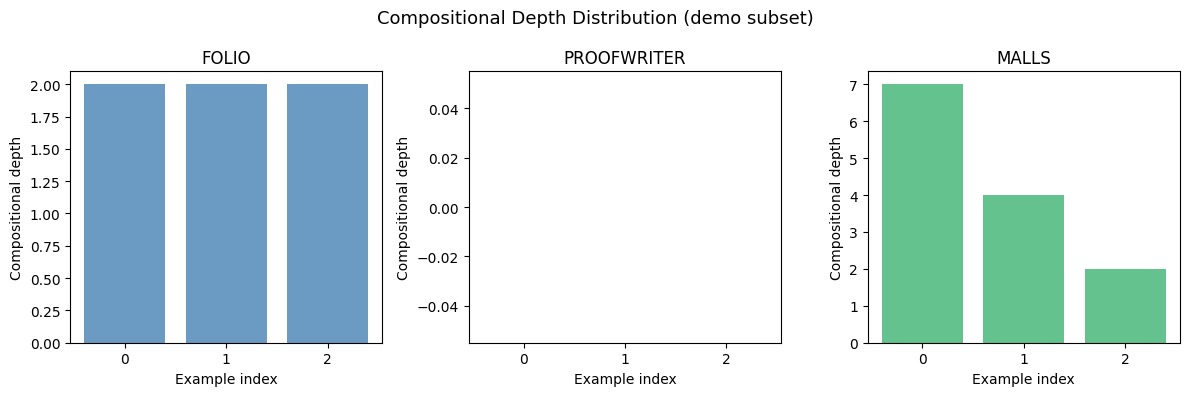

In [9]:
# Dataset summary table
meta = data["metadata"]
print("=" * 60)
print("FOLIO + ProofWriter + MALLS NL-FOL Dataset")
print("=" * 60)
print(f"{'Source':<20} {'Examples':>10} {'Has FOL':>10}")
print("-" * 42)

dataset_counts = {}
for ds in data["datasets"]:
    name = ds["dataset"]
    count = len(ds["examples"])
    has_fol = sum(1 for e in ds["examples"] if e["output"])
    dataset_counts[name] = {"count": count, "has_fol": has_fol}
    print(f"{name:<20} {count:>10} {has_fol:>10}")

print("-" * 42)
total = sum(v["count"] for v in dataset_counts.values())
print(f"{'TOTAL':<20} {total:>10}")
print()
print(f"Alignment-validation rows: {meta['alignment_validation_count']}")
print(f"Pilot rows:                {meta['pilot_count']}")
print()
print("Metadata:")
for k, v in meta["sources"].items():
    print(f"  {k}: {v}")

# Depth distribution from demo examples
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Compositional Depth Distribution (demo subset)", fontsize=13)

colors = ["steelblue", "coral", "mediumseagreen"]
for ax, ds, color in zip(axes, data["datasets"], colors):
    examples = ds["examples"]
    depths = [e["metadata_compositional_depth"] for e in examples]
    ax.bar(range(len(depths)), depths, color=color, alpha=0.8)
    ax.set_title(ds["dataset"].upper())
    ax.set_xlabel("Example index")
    ax.set_ylabel("Compositional depth")
    ax.set_xticks(range(len(depths)))

plt.tight_layout()
plt.show()